<a href="https://colab.research.google.com/github/mehedihasan-cse/Open-Source/blob/main/GDELT_Code_Exploration_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
!pip install pandas scikit-learn nltk transformers torch matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [90]:
df = pd.read_csv('/content/GKG_with_text.csv')

In [91]:
df.head(1)

,ArticleDate,ArticleDateTime,SourceCommonName,Headline,V2Tone,V2Themes,V2Persons,V2Organizations,Quotations,Amounts,Dates,GCAM,DocumentIdentifier,Extracted_Text,Word_Count
0,3/1/2026,2026-03-01T17:00:00,westerntelegraph.co.uk,How have West Wales house prices changed in th...,"-0.900900900900901,1.8018018018018,2.702702702...","TAX_ECON_PRICE,98;TAX_ECON_PRICE,243;TAX_ECON_...",NaN,NaN,NaN,"3,counties,932;",NaN,"wc:320,c12.1:25,c12.10:47,c12.11:2,c12.12:16,c...",https://www.westerntelegraph.co.uk/news/258909...,"It is the only county in west Wales to do so, ...",336


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ArticleDate         681 non-null    object
 1   ArticleDateTime     681 non-null    object
 2   SourceCommonName    681 non-null    object
 3   Headline            681 non-null    object
 4   V2Tone              681 non-null    object
 5   V2Themes            681 non-null    object
 6   V2Persons           629 non-null    object
 7   V2Organizations     552 non-null    object
 8   Quotations          276 non-null    object
 9   Amounts             607 non-null    object
 10  Dates               244 non-null    object
 11  GCAM                681 non-null    object
 12  DocumentIdentifier  681 non-null    object
 13  Extracted_Text      674 non-null    object
 14  Word_Count          681 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 79.9+ KB


In [93]:
df['ArticleDate'] = pd.to_datetime(df['ArticleDate'])

In [94]:
df = df.drop(columns=['Amounts','Headline', 'GCAM', 'Dates', 'DocumentIdentifier', 'ArticleDateTime', 'Quotations'])

In [33]:
df.isnull().sum()

,0
ArticleDate,0
SourceCommonName,0
V2Tone,0
V2Themes,0
V2Persons,52
V2Organizations,129
Extracted_Text,7
Word_Count,0


In [95]:
df.dropna(subset=['Extracted_Text'], inplace=True)

In [35]:
df.isnull().sum()

,0
ArticleDate,0
SourceCommonName,0
V2Tone,0
V2Themes,0
V2Persons,51
V2Organizations,129
Extracted_Text,0
Word_Count,0


In [36]:
df.loc[df['Word_Count'].idxmax(), 'Extracted_Text']
#df['Word_Count'].idxmax()

"From 10 Feb 2026 09.59 EST Starmer insists he will 'never walk away' from task he has to change UK, as he urges Labour to stop feuding Keir Starmer is speaking at an event in Hertfordshire. He starts with a reference to the events of yesterday – saying there has been a lot of politics around recently. But he is focused on the cost of living, he says. He says he knows what it is like to struggle, because when he was growing up his family couldn’t always pay their bills. He says he leads the most working-class cabinet in history. He says people are still being held back by their backgrounds. He says that the system did not work for people like his brother, who spent “his adult life wandering from job to job in virtual poverty”. And other people are in the same situtation, he says. He says he is fighting to help “young people who don’t get the opportunities they deserve”, and the “millions of people held back because of a system that doesn’t work for them”. He says he wants to ensure peo

In [96]:
df['Extracted_Text'] = df['Extracted_Text'].str.lower()

Remove html tags using Regular expressions

In [38]:
import re
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

In [97]:
import re
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)
df['Extracted_Text']=df['Extracted_Text'].apply(remove_html_tags)

In [40]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [41]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str): return ''
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize, remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(cleaned_words)

In [98]:
df['Extracted_Text'] = df['Extracted_Text'].apply(preprocess_text)
display(df.head(2))

,ArticleDate,SourceCommonName,V2Tone,V2Themes,V2Persons,V2Organizations,Extracted_Text,Word_Count
0,2026-03-01,westerntelegraph.co.uk,"-0.900900900900901,1.8018018018018,2.702702702...","TAX_ECON_PRICE,98;TAX_ECON_PRICE,243;TAX_ECON_...",NaN,NaN,county west wale according latest uk house pri...,336
1,2026-03-01,dailymail.co.uk,"-1.1611030478955,3.4833091436865,4.64441219158...","TAX_FNCACT_BOSS,2707;GENERAL_HEALTH,3805;HEALT...","Jumeirah Fairmont,3117;Reem Al Hashimy,3965;Ha...","Sotheby,1943",missile strike dubai come profound shock tiny ...,610


In [99]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 2. Load FinBERT model and tokenizer
model_name = 'yiyanghkust/finbert-tone'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

def get_finbert_sentiment(text, max_length=512):
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=max_length, return_overflowing_tokens=True, stride=0).to(device)
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']
    chunk_sentiments = []
    for i in range(len(input_ids)):
        with torch.no_grad():
            outputs = model(input_ids=input_ids[i:i+1], attention_mask=attention_mask[i:i+1])
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        chunk_sentiments.append(probs[1] - probs[2])
    return np.mean(chunk_sentiments)

print('Calculating FinBERT sentiment scores...')
df['FinBERT_Sentiment'] = df['Extracted_Text'].apply(get_finbert_sentiment)
print('FinBERT analysis complete.')
display(df[['ArticleDate', 'FinBERT_Sentiment']].head())

Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating FinBERT sentiment scores...
FinBERT analysis complete.


,ArticleDate,FinBERT_Sentiment
0,2026-03-01,0.718114
1,2026-03-01,-0.001524
2,2026-03-01,0.000029
3,2026-03-01,-0.232770
4,2026-03-01,0.040336


### Full-Text Sentiment Analysis (FinBERT Chunking)
Now that we've verified the model works, let's process the entire dataset. This function splits long articles into chunks, calculates sentiment for each, and returns the average.

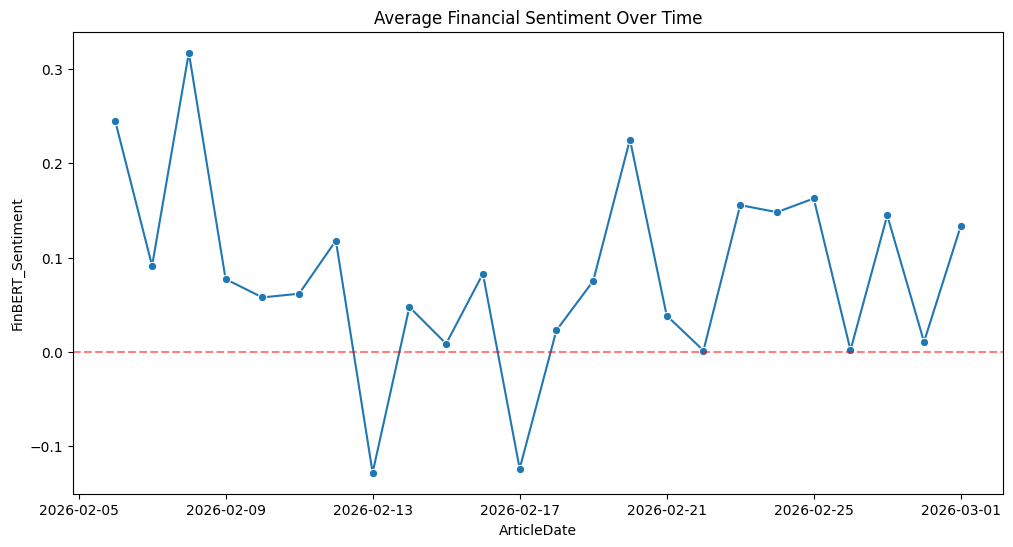

In [100]:
def categorize_score(score):
    if score > 0.05: return 'Positive'
    if score < -0.05: return 'Negative'
    return 'Neutral'

df['Sentiment_Label'] = df['FinBERT_Sentiment'].apply(categorize_score)
daily_sentiment = df.groupby('ArticleDate')['FinBERT_Sentiment'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sentiment, x='ArticleDate', y='FinBERT_Sentiment', marker='o')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Average Financial Sentiment Over Time')
plt.show()

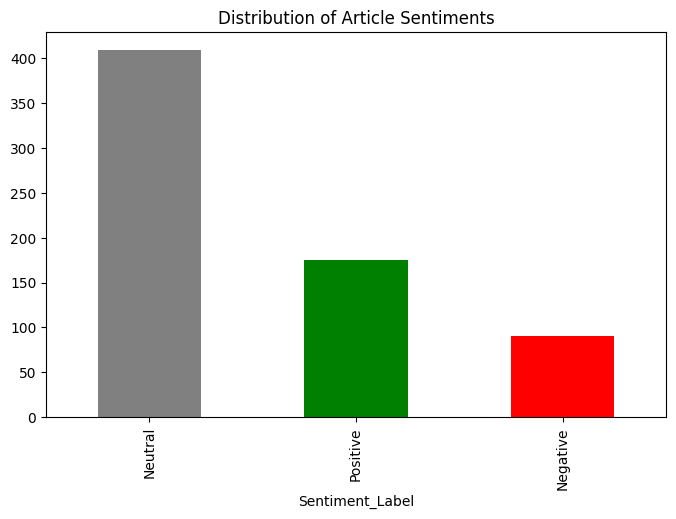

,count
Sentiment_Label,
Neutral,409
Positive,175
Negative,90


In [101]:
sentiment_dist = df['Sentiment_Label'].value_counts()
plt.figure(figsize=(8, 5))
sentiment_dist.plot(kind='bar', color=['gray', 'green', 'red'])
plt.title('Distribution of Article Sentiments')
plt.show()
display(sentiment_dist)

### Research Validation: Comparing FinBERT with GDELT V2Tone
To justify our labeling, we can compare our FinBERT scores with the `V2Tone` score provided by GDELT. V2Tone is a common research benchmark calculated by counting positive and negative words in the document. We will parse the first value from the V2Tone string, which represents the 'common' sentiment score.

Correlation: 0.3317


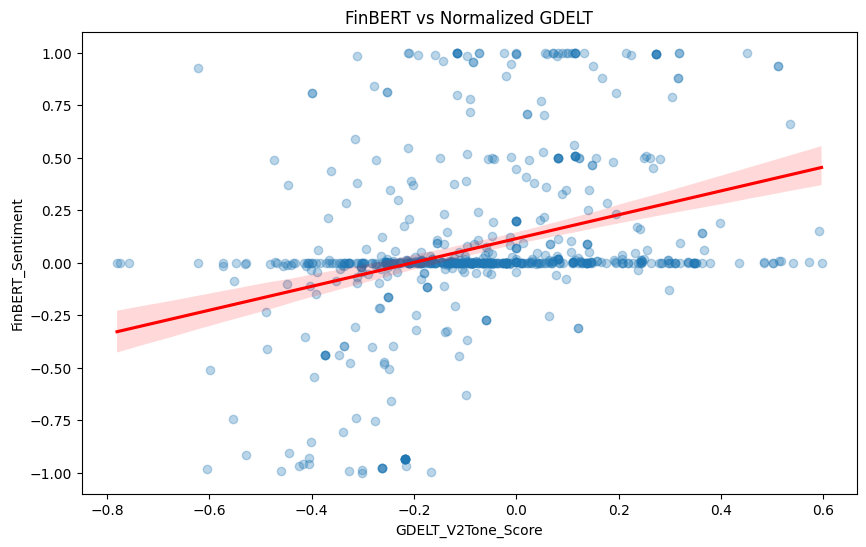

In [102]:
def extract_and_normalize_v2tone(tone_str):
    try:
        raw_score = float(tone_str.split(',')[0])
        return raw_score / 10.0
    except:
        return 0.0

df['GDELT_V2Tone_Score'] = df['V2Tone'].apply(extract_and_normalize_v2tone)
correlation = df['FinBERT_Sentiment'].corr(df['GDELT_V2Tone_Score'])
print(f'Correlation: {correlation:.4f}')

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDELT_V2Tone_Score', y='FinBERT_Sentiment', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('FinBERT vs Normalized GDELT')
plt.show()

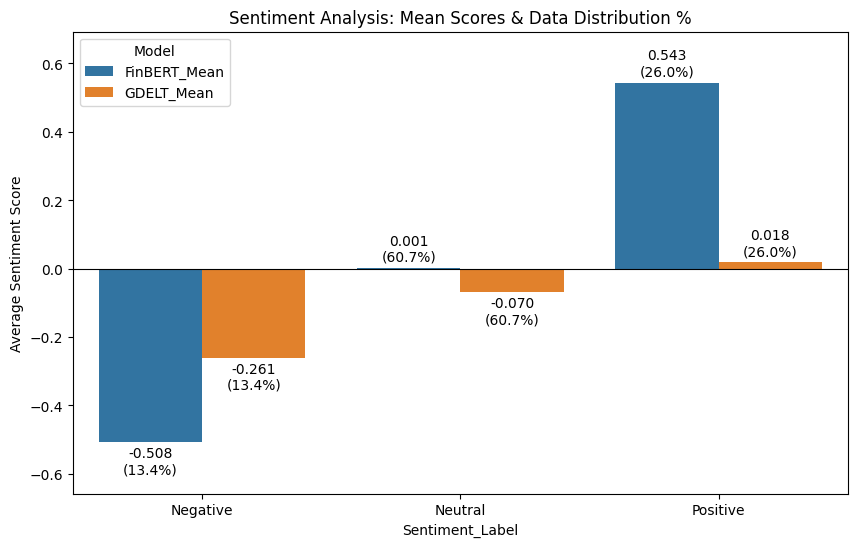

,FinBERT_Mean,GDELT_Mean,Count,Percentage
Sentiment_Label,,,,
Negative,-0.507571,-0.260508,90,13.353116
Neutral,0.000757,-0.069521,409,60.682493
Positive,0.543182,0.018247,175,25.964392


In [111]:
# Group and calculate means for static plotting
comparison_cols = df.groupby('Sentiment_Label')[['FinBERT_Sentiment', 'GDELT_V2Tone_Score']].mean().reset_index()

# Reshape data for seaborn
comparison_melted = comparison_cols.melt(id_vars='Sentiment_Label', var_name='Model', value_name='Average Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_melted, x='Sentiment_Label', y='Average Score', hue='Model')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Score Comparison: FinBERT vs GDELT')
plt.show()

display(comparison_cols.set_index('Sentiment_Label'))

### Row-Level Column Comparison
This table displays the direct alignment between the FinBERT sentiment we calculated and the pre-existing GDELT V2Tone score for individual articles.

In [112]:
# Selecting a sample to show the column-to-column relationship
comparison_table = df[['ArticleDate', 'FinBERT_Sentiment', 'GDELT_V2Tone_Score', 'Sentiment_Label']].head(15)

# Displaying the table
display(comparison_table)

,ArticleDate,FinBERT_Sentiment,GDELT_V2Tone_Score,Sentiment_Label
0,2026-03-01,0.718114,-0.090090,Positive
1,2026-03-01,-0.001524,-0.116110,Neutral
2,2026-03-01,0.000029,0.285714,Neutral
3,2026-03-01,-0.232770,-0.488432,Negative
4,2026-03-01,0.040336,-0.047978,Neutral
5,2026-03-01,0.546007,-0.211433,Positive
6,2026-03-01,0.016552,-0.253036,Neutral
7,2026-03-01,-0.087791,-0.551471,Negative
8,2026-03-01,0.015086,0.297340,Neutral
9,2026-03-01,0.015086,0.297340,Neutral


### Qualitative Analysis: FinBERT vs. GDELT Discrepancies
We will now identify 'Conflict' cases where the models disagree on the direction of sentiment. This allows for a manual 'sanity check' of the text to see if FinBERT's transformer-based context awareness outperforms GDELT's dictionary-based approach.

In [114]:
import pandas as pd

# Identify 'Conflict' rows where models have opposite polarities
# Using the 0.05 threshold for FinBERT and a corresponding 0.1 threshold for GDELT
conflicts = df[
    ((df['FinBERT_Sentiment'] > 0.05) & (df['GDELT_V2Tone_Score'] < -0.1)) |
    ((df['FinBERT_Sentiment'] < -0.05) & (df['GDELT_V2Tone_Score'] > 0.1))
].copy()

# Calculate Absolute Gap for the identified conflicts
# We use the raw GDELT_V2Tone_Score here as it's already on a comparable scale (-1 to 1)
conflicts['Absolute_Gap'] = (conflicts['FinBERT_Sentiment'] - conflicts['GDELT_V2Tone_Score']).abs()

print(f"Found {len(conflicts)} articles with major polarity disagreement.")

# Sort by Absolute_Gap to find the most contentious cases
top_conflicts = conflicts.sort_values(by='Absolute_Gap', ascending=False).head(10)

if not top_conflicts.empty:
    display(top_conflicts[['ArticleDate', 'FinBERT_Sentiment', 'GDELT_V2Tone_Score', 'Absolute_Gap']])
else:
    print("No conflicts found with current thresholds.")

Found 50 articles with major polarity disagreement.


,ArticleDate,FinBERT_Sentiment,GDELT_V2Tone_Score,Absolute_Gap
177,2026-02-24,0.927225,-0.623100,1.550325
252,2026-02-20,0.985211,-0.310766,1.295977
158,2026-02-24,0.999992,-0.210843,1.210836
166,2026-02-24,0.808369,-0.399306,1.207675
165,2026-02-24,0.808369,-0.399306,1.207675
262,2026-02-20,0.998695,-0.208955,1.207650
280,2026-02-19,0.989496,-0.191489,1.180985
409,2026-02-17,0.987929,-0.158730,1.146660
525,2026-02-12,0.842815,-0.277778,1.120593
628,2026-02-08,0.998910,-0.116822,1.115733


### Detailed Text Inspection
Use the cell below to print the full text of a specific article where the models disagree to analyze the financial context.

In [73]:
# Change the index to inspect different conflicting articles from the table above
if not top_conflicts.empty:
    target_index = top_conflicts.index[0]
    print(f"--- INSPECTING INDEX: {target_index} ---")
    print(f"FinBERT Score: {df.loc[target_index, 'FinBERT_Sentiment']:.4f} ({df.loc[target_index, 'Sentiment_Label']})")
    print(f"GDELT Score: {df.loc[target_index, 'GDELT_V2Tone_Score']:.4f}")
    print("\nFULL TEXT:")
    print(df.loc[target_index, 'Extracted_Text'])
else:
    print("No major conflicts found in the current threshold.")

Date: 2026-02-24 00:00:00,Processed Word Count: 396
FinBERT Score: 0.9272 (Positive),GDELT Score: -6.2310
